In [1]:
import sys 
import os 

sys.path.append(os.path.join('..', '..'))

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import itertools 
import matplotlib.pyplot as plt

In [3]:
data_dir = Path("../../data/base_de_dados_final/")
arquivo = data_dir / "base_sigesguarda_socioeconomica.csv"

In [4]:
df = pd.read_csv(arquivo, sep=";", encoding="latin1", dtype=str)

In [5]:
df.head()

,ATENDIMENTO_BAIRRO_NOME,FLAG_EQUIPAMENTO_URBANO,FLAG_FLAGRANTE,LOGRADOURO_NOME,NATUREZA1_DEFESA_CIVIL,NATUREZA1_DESCRICAO,NATUREZA2_DEFESA_CIVIL,NATUREZA2_DESCRICAO,NATUREZA3_DEFESA_CIVIL,NATUREZA3_DESCRICAO,...,pct_analfabetismo_15mais_estimado,domicilios_particulares_ocupados_estimado,sem_banheiro_sanitario_estimado,pct_sem_banheiro_sanitario_estimado,esgotamento_precario_estimado,pct_esgotamento_precario_estimado,sem_rede_geral_agua_estimado,pct_sem_rede_geral_agua_estimado,lixo_destino_inadequado_estimado,pct_lixo_destino_inadequado_estimado
0,cidade industrial,0,0,davi xavier da silva,0,alarmes,0,NaN,0,NaN,...,3.34,52161,47,0.09,1359,2.61,97,0.19,22,0.04
1,fazendinha,1,0,carlos klemtz,0,roubo,0,NaN,0,NaN,...,2.51,8980,3,0.04,104,1.16,6,0.07,2,0.02
2,uberaba,0,0,doutor joao de paula moura brito,0,animais,0,NaN,0,NaN,...,2.51,21881,23,0.11,1296,5.92,273,1.25,10,0.04
3,sitio cercado,0,0,edgard cavalcanti de albuquerque,0,animais,0,NaN,0,NaN,...,3.39,35174,35,0.1,331,0.94,97,0.28,3,0.01
4,tatuquara,1,0,carlos munhoz da rocha,0,alarmes,0,NaN,0,NaN,...,4.79,14960,25,0.17,1383,9.25,55,0.37,30,0.2


In [6]:
df.columns

Index(['ATENDIMENTO_BAIRRO_NOME', 'FLAG_EQUIPAMENTO_URBANO', 'FLAG_FLAGRANTE',
       'LOGRADOURO_NOME', 'NATUREZA1_DEFESA_CIVIL', 'NATUREZA1_DESCRICAO',
       'NATUREZA2_DEFESA_CIVIL', 'NATUREZA2_DESCRICAO',
       'NATUREZA3_DEFESA_CIVIL', 'NATUREZA3_DESCRICAO',
       'NATUREZA4_DEFESA_CIVIL', 'NATUREZA4_DESCRICAO',
       'NATUREZA5_DEFESA_CIVIL', 'NATUREZA5_DESCRICAO', 'OCORRENCIA_ANO',
       'OCORRENCIA_DIA_SEMANA', 'OCORRENCIA_MES', 'SECRETARIA_SIGLA',
       'SERVICO_NOME', 'NUMERO_PROTOCOLO_156', 'OCORRENCIA_DIA',
       'OCORRENCIA_HORA_HORA', 'OCORRENCIA_HORA_MINUTO', 'MADRUGADA', 'MANHA',
       'TARDE', 'NOITE', 'CRIME_VIOLENTO',
       'ATENDIMENTO_OPERACIONAL_ASSISTENCIAL', 'ACIDENTE_TRANSITO',
       'ACIDENTE_NATURAL', 'CRIME_PATRIMONIAL', 'CRIME_ADMINISTRACAO_PUBLICA',
       'CRIME_HONRA_DISCRIMINACAO', 'CRIME_CRIANCA_ADOLESCENTE',
       'CRIME_FRAUDE_DOCUMENTAL', 'CRIME_DROGAS_SUBSTANCIAS',
       'CRIME_ORDEM_PUBLICA', 'RISCO_ESTRUTURAL',
       'EXPLOSIVOS_E_PR

In [7]:
cols_int = [
    "FLAG_EQUIPAMENTO_URBANO",
    "FLAG_FLAGRANTE",
    "NATUREZA1_DEFESA_CIVIL",
    "NATUREZA2_DEFESA_CIVIL",
    "NATUREZA3_DEFESA_CIVIL",
    "NATUREZA4_DEFESA_CIVIL",
    "NATUREZA5_DEFESA_CIVIL",
    "OCORRENCIA_MES",
    "OCORRENCIA_DIA",
    "MADRUGADA",
    "MANHA",
    "TARDE",
    "NOITE",
    "CRIME_VIOLENTO",
    "ATENDIMENTO_OPERACIONAL_ASSISTENCIAL",
    "ACIDENTE_TRANSITO",
    "CRIME_PATRIMONIAL",
    "CRIME_DROGAS_SUBSTANCIAS",
    "CRIME_ORDEM_PUBLICA",
    "ano",
    "ACIDENTE_NATURAL",
    "RISCO_ESTRUTURAL",
    "EXPLOSIVOS_E_PRODUTOS_PERIOGOSOS",
    "MATERIAIS_OBJETOS",
    "CRIME_ADMINISTRACAO_PUBLICA",
    "PESSOAS_DESAPARECIDAS",
    "CRIME_FRAUDE_DOCUMENTAL",
    "CRIME_CRIANCA_ADOLESCENTE",
    "CRIME_HONRA_DISCRIMINACAO",
]

In [8]:
for col in cols_int:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("int64")

In [9]:
cols_float = [
    "populacao_estimado",
    "rendimento_medio_responsavel_sm_estimado",
    "pct_alfabetizacao_15mais_estimado",
    "pct_sem_banheiro_sanitario_estimado",
    "pct_esgotamento_precario_estimado",
    "pct_sem_rede_geral_agua_estimado",
    "pct_lixo_destino_inadequado_estimado",
]

In [10]:
for col in cols_float:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

### Dropando colunas desnecessárias

In [11]:
df = df.drop(columns=["LOGRADOURO_NOME", "NATUREZA1_DESCRICAO", "NATUREZA2_DESCRICAO", "NATUREZA3_DESCRICAO", "NATUREZA4_DESCRICAO", "NATUREZA5_DESCRICAO",
                      "OCORRENCIA_ANO", "NUMERO_PROTOCOLO_156", "OCORRENCIA_HORA_HORA", "OCORRENCIA_HORA_MINUTO", "tipo_estimativa", "SECRETARIA_SIGLA",
                      "resp_domicilios_particulares_estimado", "alfabetizados_15mais_estimado", "analfabetos_15mais_estimado", "pct_analfabetismo_15mais_estimado",
                      "domicilios_particulares_ocupados_estimado", "esgotamento_precario_estimado", "sem_banheiro_sanitario_estimado", "sem_rede_geral_agua_estimado",
                      "lixo_destino_inadequado_estimado", "pop_15mais_estimado", "SERVICO_NOME"
                      ])

In [12]:
df = df[df["ano"] != 2026]

Seguindo o que foi discutivo em '03 - Projeto/Projeto.pdf', vamos agrupar as colunas: 

- `ACIDENTE_NATURAL`; 
- `RISCO_ESTRUTURAL`;
- `EXPLOSIVOS_E_PRODUTOS_PERIGOSOS`
- `MATERIAIS_OBJETOS`;
- `CRIME_ADMINISTRACAO_PUBLICA`;
- `PESSOAS_DESAPARECIDAS`;
- `CRIME_FRAUDE_DOCUMENTAL`;
- `CRIME_CRIANCA_ADOLESCENTE`;
- `CRIME_HONRA_DISCRIMINACAO`

em uma única coluna `OUTROS`, por serem pouco representativas. 

In [13]:
classes_outros = [
    "ACIDENTE_NATURAL",
    "RISCO_ESTRUTURAL",
    "EXPLOSIVOS_E_PRODUTOS_PERIOGOSOS",
    "MATERIAIS_OBJETOS",
    "CRIME_ADMINISTRACAO_PUBLICA",
    "PESSOAS_DESAPARECIDAS",
    "CRIME_FRAUDE_DOCUMENTAL",
    "CRIME_CRIANCA_ADOLESCENTE",
    "CRIME_HONRA_DISCRIMINACAO"
]

df["OUTROS"] = df[classes_outros].any(axis=1).astype(int)

df = df.drop(columns=classes_outros)

In [14]:
df.columns

Index(['ATENDIMENTO_BAIRRO_NOME', 'FLAG_EQUIPAMENTO_URBANO', 'FLAG_FLAGRANTE',
       'NATUREZA1_DEFESA_CIVIL', 'NATUREZA2_DEFESA_CIVIL',
       'NATUREZA3_DEFESA_CIVIL', 'NATUREZA4_DEFESA_CIVIL',
       'NATUREZA5_DEFESA_CIVIL', 'OCORRENCIA_DIA_SEMANA', 'OCORRENCIA_MES',
       'OCORRENCIA_DIA', 'MADRUGADA', 'MANHA', 'TARDE', 'NOITE',
       'CRIME_VIOLENTO', 'ATENDIMENTO_OPERACIONAL_ASSISTENCIAL',
       'ACIDENTE_TRANSITO', 'CRIME_PATRIMONIAL', 'CRIME_DROGAS_SUBSTANCIAS',
       'CRIME_ORDEM_PUBLICA', 'ano', 'populacao_estimado',
       'rendimento_medio_responsavel_sm_estimado',
       'pct_alfabetizacao_15mais_estimado',
       'pct_sem_banheiro_sanitario_estimado',
       'pct_esgotamento_precario_estimado', 'pct_sem_rede_geral_agua_estimado',
       'pct_lixo_destino_inadequado_estimado', 'OUTROS'],
      dtype='str')

### Métodos de normalização

A normalização consiste em uma operação aplicada aos dados brutos com o objetivo de redimensioná-los ou transformá-los, de modo que todas as variáveis contribuam de forma comparável para a análise. Em aplicações de aprendizado de máquina e análise estatística, essa etapa é importante principalmente para lidar com dois problemas recorrentes: a diferença de escala entre as variáveis e a presença de valores extremos (outliers), que podem dominar os cálculos e distorcer os resultados.

No contexto deste estudo, é fundamental preservar a relação entre os valores extremos das variáveis socioeconômicas, uma vez que esses extremos representam justamente as diferenças entre os bairros com melhores e piores condições de qualidade de vida. Dessa forma, método que comprimem excessivamente os outliers poderiam reduzir informações relevantes para a construção do índice.

Por esse motivo, será utilizado o método **Min-Max Normalization (MNN)**. Esse método realiza uma transformação linear dos dados, utilzando os valores mínimo e máximo observados em cada variável para redimensioná-la para um intervalo previamente definido. Neste trabalho, os dados serão normalizados para o intervalo [0, 1], seguindo a transformação:

$$
x'_{i, n} = \left[\frac{x_{i, n} - min(x_{i})}{max(x_{i}) - min(x_{i})}\right](\text{nMax} - \text{nMin}) + \text{nMin}
$$

onde:

- $min(x_i)$ é o valor mínimo da feature $i$;
- $max(x_i)$ é o valor máximo da feature $i$;
- $\text{nMax}$ e $\text{nMin}$ correspondem, respectivamente, aos limites inferior e superior do intervalo desejado.


## Índice de qualidade de vida (IQV)

Para o desenvolvimento do índice de qualidade de vida por bairro, serão utilizadas apenas variáveis proporcionais e indicadores percentuais, uma vez que variáveis absolutas podem refletir principalmente o tmaanho populacional do bairro, dificultando comparações diretas entre diferentes regiões. 

Os indicadores selecionados foram divididos em dois grupos, de acordo com a interpretação de seus valores em relação à qualidade de vida.

### 1. Indicadores positivos

Neste grupo, valores mais elevados indicam melhores condições socioeconômicas e, consequentemente, maior qualidade de vida:

- `rendimento_medio_responsavel_sm_estimado`;
- `pct_alfabetizacao_15mais_estimado`.

Como a variável de rendimento apresenta distribuição assimétrica à direita (*right-skewed*), será aplicada inicialmente uma transformação logarítmica, com o objetivo de reduzir a influência de valores extremos e melhorar a distribuição dos dados antes da normalização.

### 1. Indicadores negativos

Neste grupo, valores mais elevados representam condições mais precárias de infraestrutura urbana e sanemaneto básico, indicando pior qualidade de vida:

- `pct_sem_banheiro_sanitario_estimado`;
- `pct_esgotamento_precario_estimado`;
- `pct_sem_rede_geral_agua_estimado`;
- `pct_lixo_destinado_inadequado_estimado`.


Após a selação das variáveis, será aplicada a normalização Min-Max para transformar todos os indicadores em uma mesma escala no intervalo [0, 1].

Para os indicadores positivos, será utilizada a transformação:

$$
x_{norm} = \frac{x - min(x)}{max(x) - min(x)}
$$

de modo que:

- o menor valor observado seja transformado em 0;
- o maior valor observado seja transformado em 1.

Por fim, o IQV de cada bairro b será calculado a partir da média aritmética dos indicadores normalizados:

$$
\text{IQV}_{b} = \frac{100}{k}\sum_{j = 1}^{k}x_{k, j}^{\text{norm}}
$$

onde:

- $k$ representa o número total de indicadores utilizados;
- $x_{b, j}^{\text{norm}}$ corresponde ao valor normalizado do indicador $j$ para o bairro $b$.

A multiplicações por 100 tem como objetivo facilitar a interpretação do índice final, que passará a variar entre 0 e 100, sendo que valores mais elevados indicam melhores condições relativas de qualidade de vida.

Para os indicadores negativos, será utilizada a transformação inversa:

$$
x_{norm} = \frac{max(x) - x}{max(x) - min(x)}
$$

Nesse caso:

- bairros em piores condições recebem valores próximos de 0;
- bairros em melhores condições recebem valores próximos de 1.

Assim, todos os indcadores passam a possuir a mesma interpretação: valores mais próximos de 1 representam melhores condições d equalidade de vida.

In [15]:
def minmax(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    
    df = df.copy()

    for column in columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

        max = df[column].max()
        min = df[column].min()

        diff = max - min

        if diff == 0:
            df[column + "_norm"] = 0
        else:
            df[column + "_norm"] = (df[column] - min) / diff

    return df

In [16]:
def maxmin(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:

    df = df.copy()

    for column in columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

        max = df[column].max()
        min = df[column].min()

        diff = max - min 

        if diff == 0:
            df[column + "_norm"] = 0
        else:
            df[column + "_norm"] = (max - df[column]) / diff
    
    return df

Agora, visualizaremos a distribuição do rendimento médio do responsável em salários mínimos:

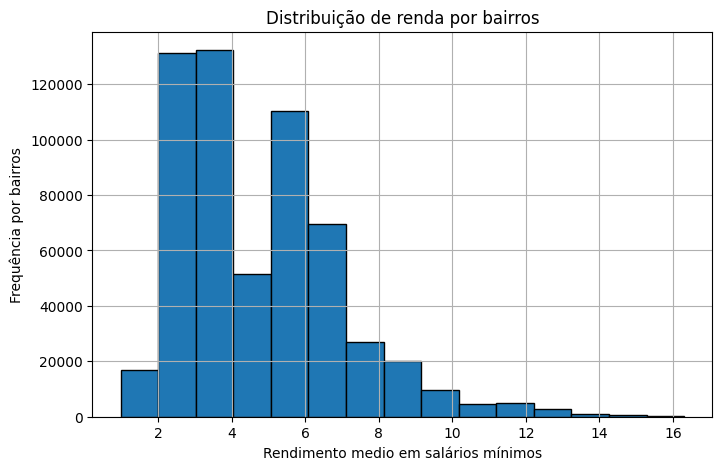

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df["rendimento_medio_responsavel_sm_estimado"], bins=15, edgecolor="black")
plt.xlabel("Rendimento medio em salários mínimos")
plt.ylabel("Frequência por bairros")
plt.title("Distribuição de renda por bairros")
plt.grid(True)
plt.show()

Aplicando o logaritmo na base 10, a distribuição passa a ser:

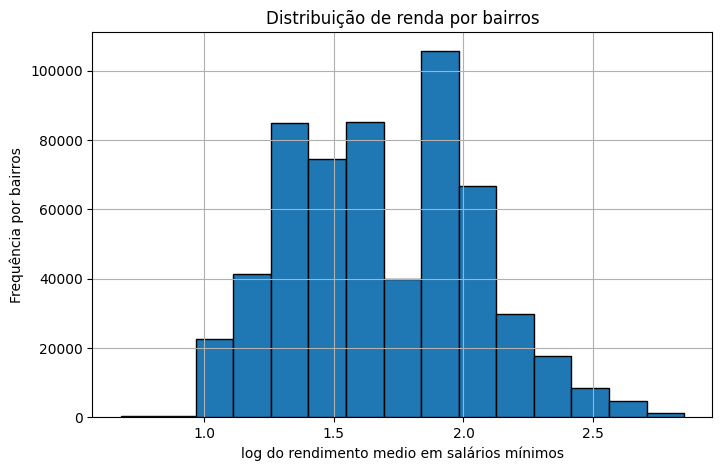

In [18]:
df["log_rendimento"] = np.log1p(df["rendimento_medio_responsavel_sm_estimado"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_rendimento"], bins=15, edgecolor="black")
plt.xlabel("log do rendimento medio em salários mínimos")
plt.ylabel("Frequência por bairros")
plt.title("Distribuição de renda por bairros")
plt.grid(True)
plt.show()

Faremos o mesmo para a populacao:

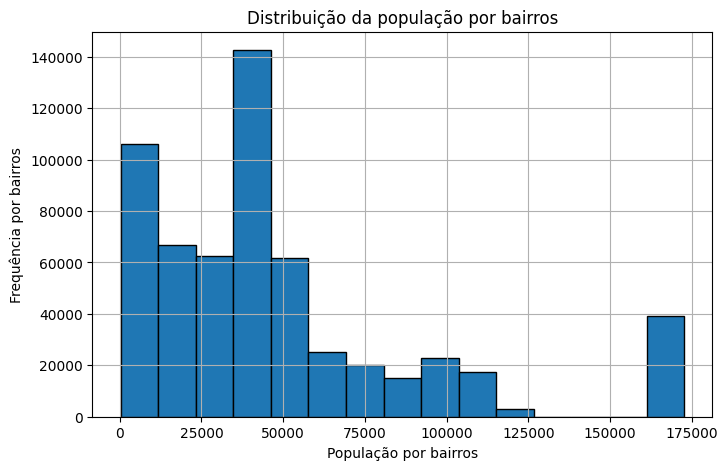

In [19]:
df["populacao_estimado"] = pd.to_numeric(df["populacao_estimado"], errors="coerce")

plt.figure(figsize=(8, 5))
plt.hist(df["populacao_estimado"], bins=15, edgecolor="black")
plt.xlabel("População por bairros")
plt.ylabel("Frequência por bairros")
plt.title("Distribuição da população por bairros")
plt.grid(True)
plt.show()

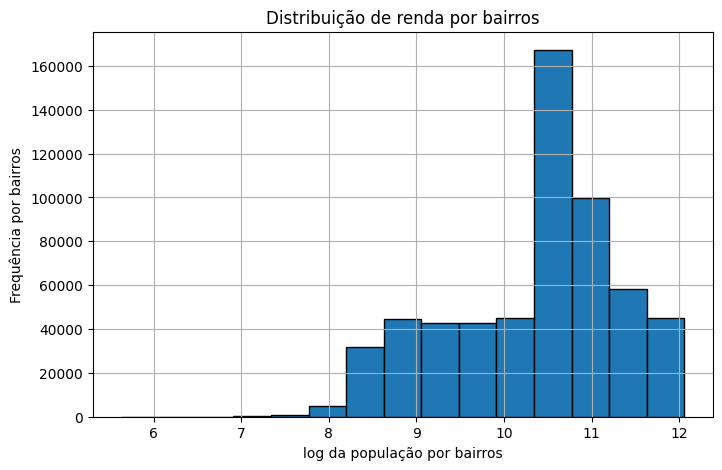

In [20]:
df["log_pop"] = np.log1p(df["populacao_estimado"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_pop"], bins=15, edgecolor="black")
plt.xlabel("log da população por bairros")
plt.ylabel("Frequência por bairros")
plt.title("Distribuição de renda por bairros")
plt.grid(True)
plt.show()

In [21]:
variaveis_positivas = [
    "rendimento_medio_responsavel_sm_estimado",
    "pct_alfabetizacao_15mais_estimado"
]

variaveis_negativas = [
    "pct_sem_banheiro_sanitario_estimado",
    "pct_esgotamento_precario_estimado",
    "pct_sem_rede_geral_agua_estimado",
    "pct_lixo_destino_inadequado_estimado"
]

In [22]:
df = minmax(df, variaveis_positivas)
df = maxmin(df, variaveis_negativas)

In [23]:
cols_originais = variaveis_positivas + variaveis_negativas
cols_norm = [c + "_norm" for c in cols_originais]

Calculando o IQV por bairro:

In [24]:
df["IQV"] = df[cols_norm].mean(axis=1) * 100

In [25]:
df.groupby("ATENDIMENTO_BAIRRO_NOME")["IQV"].mean()

ATENDIMENTO_BAIRRO_NOME
abranches         79.128974
agua verde        91.602417
ahu               92.260368
alto boqueirao    78.083012
alto da gloria    91.583693
                    ...    
uberaba           79.640563
umbara            73.776691
vila izabel       89.246193
vista alegre      87.459619
xaxim             82.107502
Name: IQV, Length: 75, dtype: float64

In [26]:
iqv_bairros = (
    df.groupby("ATENDIMENTO_BAIRRO_NOME")["IQV"]
    .mean()
    .reset_index()
)

In [27]:
ranking = (
    iqv_bairros
    .sort_values("IQV", ascending=False)
    .reset_index(drop=True)
)

ranking["ranking"] = ranking.index + 1

pd.set_option("display.max_rows", None)

ranking

,ATENDIMENTO_BAIRRO_NOME,IQV,ranking
0,batel,96.155138,1
1,mossungue,93.212606,2
2,jardim social,92.718985,3
3,hugo lange,92.420979,4
4,cabral,92.405556,5
5,ahu,92.260368,6
6,agua verde,91.602417,7
7,alto da gloria,91.583693,8
8,juveve,90.896799,9
9,alto da xv,90.596729,10


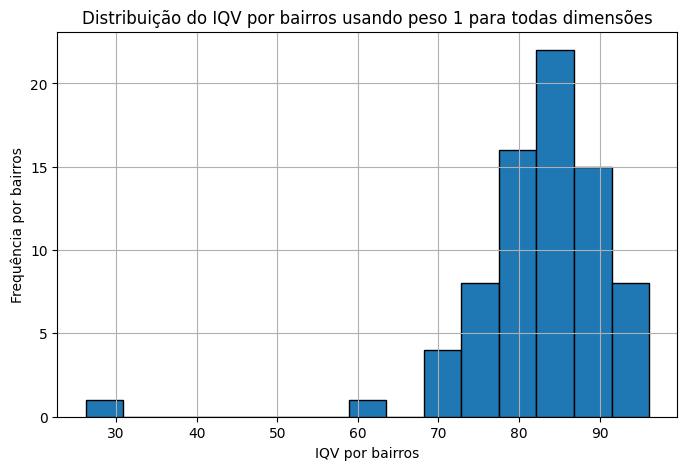

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(ranking["IQV"], bins=15, edgecolor="black")
plt.xlabel("IQV por bairros")
plt.ylabel("Frequência por bairros")
plt.title("Distribuição do IQV por bairros usando peso 1 para todas dimensões")
plt.grid(True)
plt.show()

Como resultado final, o bairro Caximba ficou com um IQV muito baixo. Agora, analisaremos o por que. O primeiro chute é que a forma com que o IQV foi calculada não é a mais adequada.

Inicialmente, o IQV foi calculado para cada bairro como sendo uma média dos indicadores normalizados. Nessa formulação, todos os indicadores contribuem igualmente para o índice, isto é, cada variável possui pelo relativo equivalente a $1/k$. 

Entretanto, essa escolha de pesos iguais representa apenas uma das possíveis formas de agregação dos indicadores. Como não há garantia de que todos os componentes do IQV possuam a mesma relevância na caracterização da qualidade de vida dos bairros, torna-se necessário validar a robustez do índice em relação à variação desses pesos. 

Para isso, será realizada uma análise de sensibilidade, introduzindo um fator de ponderação $\omega_j$, associado a cada indicador. O IQV ponderado passa a ser definido por:

$$
IQV_{b} = 100 \sum_{j =1}^{k} \omega_{j}x_{b, j}^{ \text{norm}}
$$

com as restrições:

$$
\omega_{j} \geq 0
$$

e

$$
\sum_{j = 1}^{k} \omega_{j} = 1
$$

Para gerar o conjunto de pesos aleatórios, faremos:

In [29]:
def gerar_pesos(indicadores, passo=0.1, peso_minimo=0.0):
    k = len(indicadores)
    n = int(1 / passo)
    min_units = int(peso_minimo / passo)

    combinacoes = []

    for comb in itertools.product(range(min_units, n + 1), repeat=k):
        if sum(comb) == n:
            pesos = np.array(comb) * passo 
            combinacoes.append(pesos)

    pesos_df = pd.DataFrame(combinacoes, columns=indicadores)
    return pesos_df

In [30]:
pesos_df = gerar_pesos(cols_norm, passo=0.1, peso_minimo=0.1)

In [31]:
len(pesos_df)

126

In [32]:
bairro_col = "ATENDIMENTO_BAIRRO_NOME"

df_bairros = (
    df
    .groupby(bairro_col)[cols_norm]
    .mean()
    .dropna()
)

In [33]:
X = df_bairros[cols_norm].values
W = pesos_df[cols_norm].values

In [34]:
iqv_matriz = 100 * X @ W.T

In [35]:
iqv_df = pd.DataFrame(
    iqv_matriz,
    index=df_bairros.index,
    columns=[f"peso_{i}" for i in range(len(pesos_df))]
)

In [36]:
rank_df = iqv_df.rank(
    ascending=False,
    method="min"
)

In [37]:
n_bairros = len(rank_df)

In [38]:
sensibilidade = pd.DataFrame({
    "rank_medio": rank_df.mean(axis=1),
    "rank_mediano": rank_df.median(axis=1),
    "melhor_rank": rank_df.min(axis=1),
    "pior_rank": rank_df.max(axis=1),
    "amplitude_rank": rank_df.max(axis=1) - rank_df.min(axis=1),
    "desvio_rank": rank_df.std(axis=1),
    "rank_p05": rank_df.quantile(0.05, axis=1),
    "rank_p95": rank_df.quantile(0.95, axis=1),
    "freq_top10": (rank_df <= 10).mean(axis=1),
    "freq_bottom10": (rank_df >= n_bairros - 9).mean(axis=1)
})

sensibilidade = sensibilidade.sort_values("rank_mediano")

In [39]:
display(sensibilidade)

,rank_medio,rank_mediano,melhor_rank,pior_rank,amplitude_rank,desvio_rank,rank_p05,rank_p95,freq_top10,freq_bottom10
ATENDIMENTO_BAIRRO_NOME,,,,,,,,,,
batel,1.000000,1.0,1.0,1.0,0.0,0.000000,1.00,1.00,1.000000,0.000000
jardim social,2.746032,3.0,2.0,5.0,3.0,0.668569,2.00,4.00,1.000000,0.000000
hugo lange,4.325397,4.0,2.0,8.0,6.0,1.301257,3.00,6.75,1.000000,0.000000
cabral,4.539683,4.0,2.0,9.0,7.0,1.542210,2.00,8.00,1.000000,0.000000
mossungue,4.531746,4.0,2.0,9.0,7.0,2.563393,2.00,8.00,1.000000,0.000000
ahu,4.976190,5.0,2.0,7.0,5.0,1.261518,3.00,7.00,1.000000,0.000000
agua verde,7.119048,7.0,5.0,8.0,3.0,0.872762,5.00,8.00,1.000000,0.000000
alto da gloria,7.142857,7.0,4.0,9.0,5.0,1.401224,5.00,9.00,1.000000,0.000000
juveve,9.825397,10.0,7.0,15.0,8.0,1.955830,7.00,13.00,0.730159,0.000000


A análise de sensibilidade indicou que, de modo geral, o ranking dos bairros é estável diante das variações dos pesos $\omega_{j}$. No caso específico de Caximba, observa-se também que sua posição no ranking permanece associada a um desempenho desfavorável na maior parte dos indicaores considerados, especialmente aqueles relacionados ao saneamento básico e às condições de higiene. 

Assim, aplicaremos mais uma hipótese:

Para o cálculo do IQV, foram utilizadas as features:

- `rendimento_medio_responsavel_sm_estimado`;
- `pct_alfabetizacao_15mais_estimado`;
- `pct_sem_banheiro_sanitario_estimado`;
- `pct_esgotamento_precario_estimado`;
- `pct_sem_rede_geral_agua_estimado`;
- `pct_lixo_destino_inadequado_estimado`

Esses indicadores podem ser agrupados em três dimensões principais:

- renda;
- educação;
- saneamento básico e condições de higiene.

No entanto, observa-se que a dimensão de saneamento básico e condições de higiene é representada por quatro variáveis, enquanto renda e educação são representadas por apenas uma variável cada. Dessa forma, ao utilizar pesos iguais por indicador, a dimensão de saneamento passa a ter maior influência no valor final do IQV, correspondendo a quatro dos seis componentes do índice. 

Essa estrutura penaliza bairros que apresentam desempenho ruim nos indicadores de saneamento, como é o caso do Caximba. Assim, a nova hipótese de ponderação atribui peso igual para as três dimensões, fazendo:

$$
\text{Renda} = \frac{1}{3}
$$

$$
\text{Educação} = \frac{1}{3}
$$

$$
\text{Saneamento básico / condições de higiene} = \frac{1}{3}
$$

Como a dimensão de saneamento básico tem 4 indicadores, o peso dessa dimensão foi dividido igualmente entre eles. Assim, cada indicador de saneamento recebe peso $1/12$. Com isso, o IQV final passa a ser calculado por:

$$
\text{IQV}_{b} = \frac{100}{3}(x_{\text{renda, b}}^{\text{norm}} + x_{\text{alfabetização, b}}^{\text{norm}}) + \frac{100}{12}x_{\text{saneamento, b}}^{\text{norm}}
$$

onde 

$$
x_{\text{sanemanto, b}}^{\text{norm}} = x_{\text{banheiro, b}}^{\text{norm}} + x_{\text{esgotamento, b}}^{\text{norm}} + x_{\text{agua, b}}^{\text{norm}} + x_{\text{lixo, b}}^{\text{norm}}
$$

In [40]:
pesos_finais = {
    "rendimento_medio_responsavel_sm_estimado_norm": 1/3,
    "pct_alfabetizacao_15mais_estimado_norm": 1/3,
    "pct_sem_banheiro_sanitario_estimado_norm": 1/12,
    "pct_esgotamento_precario_estimado_norm": 1/12,
    "pct_sem_rede_geral_agua_estimado_norm": 1/12,
    "pct_lixo_destino_inadequado_estimado_norm": 1/12
}

In [41]:
df["IQV_final"] = 100 * sum(
    df[col] * peso for col, peso in pesos_finais.items()
)

In [42]:
ranking_iqv_ponderado = (
    df
    .groupby("ATENDIMENTO_BAIRRO_NOME")["IQV_final"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

ranking_iqv_ponderado["ranking"] = ranking_iqv_ponderado.index + 1
ranking_iqv_ponderado

,ATENDIMENTO_BAIRRO_NOME,IQV_final,ranking
0,batel,92.417916,1
1,mossungue,88.795159,2
2,cabral,85.694533,3
3,jardim social,85.675672,4
4,ahu,85.207072,5
5,hugo lange,84.850150,6
6,alto da gloria,83.403866,7
7,juveve,83.383952,8
8,agua verde,83.381982,9
9,centro civico,82.429633,10


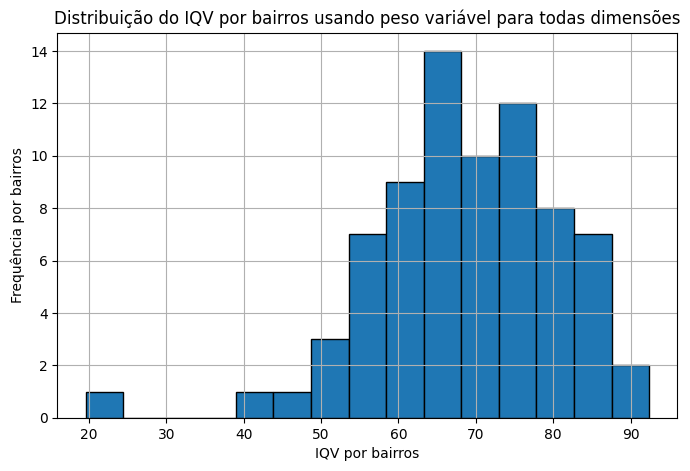

In [43]:
plt.figure(figsize=(8, 5))
plt.hist(ranking_iqv_ponderado["IQV_final"], bins=15, edgecolor="black")
plt.xlabel("IQV por bairros")
plt.ylabel("Frequência por bairros")
plt.title("Distribuição do IQV por bairros usando peso variável para todas dimensões")
plt.grid(True)
plt.show()

In [44]:
df_final = df.drop(columns=cols_originais + ["IQV"], errors="ignore")

In [45]:
arquivo_feature_engineering = data_dir / "base_feature_engineering.csv"

In [46]:
df_final.to_csv(
    arquivo_feature_engineering,
    index=False,
    sep=";",
    encoding="latin1"
)